In [2]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter 
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import CSVLoader
from langchain_core.tools import Tool
from langgraph.prebuilt import ToolNode
from typing import Annotated,Sequence, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
from typing import Literal
from pydantic import BaseModel, Field
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import tools_condition
from langchain_core.messages import HumanMessage
from pprint import pprint
from langchain_community.tools import DuckDuckGoSearchRun

c:\Users\hardi\OneDrive\Desktop\begproject_pdfchatbot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
file_path=r"C:\Users\hardi\OneDrive\Desktop\begproject_pdfchatbot\Delhi metro.csv"
csv_loader = CSVLoader(file_path)
routes = csv_loader.load()

In [4]:
urls=[
    "https://livemad-ness.blogspot.com/2016/10/a-journey-via-delhi-metro.html",
    "https://www.intrepidtravel.com/adventures/guide-delhi-metro-india/",
    "https://www.reiasindia.com/blog/delhi-metro-revolutionary-change-in-urban-transport",
]
docs=[WebBaseLoader(url).load() for url in urls]
docs_list=[item for sublist in docs for item in sublist]

In [5]:
docs_list

[Document(metadata={'source': 'https://livemad-ness.blogspot.com/2016/10/a-journey-via-delhi-metro.html', 'title': 'A journey via Delhi metro - NoMads', 'description': '', 'language': 'No language found.'}, page_content="\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nA journey via Delhi metro - NoMads\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nNoMads\n\n\n\n\nEnergy comes from knowing the truth that life is short and we need to learn to live and live to learn.\n\n\n\n\n\n\n\n Menu\n\nHome\n\nTravel\n\n\nKarnataka\n\nNorth Karnataka\nMysore\nKodagu\nMangalore-Udupi\nWestern Ghats-Karwar coast\n\n\n\nSouth\n\nKerala\nTamilnadu\nTelangana\nPuducherry\n\n\n\nWest\n\nMaharashtra\nGujarat\nGoa\n\n\n\nNorth\n\nDelhi\nHimachal Pradesh\nUttarakhand\nUttar Pradesh\n\n\n\n\nTeam\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\narchitectures\n\nDelhi\n\nMetro\n\nA journey via Delhi metro\n\n\n\n\n\n\n\n\n\nA journey via Delhi metro\n\n\n\n\n\n\n\nSanthosh Kumar B

In [6]:
embeddings = HuggingFaceEmbeddings(model="sentence-transformers/all-MiniLM-L6-v2")

In [7]:
text_splitter=RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=100,chunk_overlap=25)
blogs_split=text_splitter.split_documents(docs_list)
routes_split=text_splitter.split_documents(routes)
all_data=blogs_split+routes_split
vectorstore=Chroma.from_documents(
    documents=all_data,
    collection_name="delhi-metro",
    embedding=embeddings  
)

In [8]:
retriever=vectorstore.as_retriever()
llm=ChatGroq(model="openai/gpt-oss-120b")
retriever_tool = Tool(
    name="retriever",
    description="Search and return relevant information about Delhi Metro from the routs or blog posts",
    func=retriever.invoke)
tools=[retriever_tool]
retriever_node=ToolNode(tools)
llm_with_tool=llm.bind_tools(tools)

In [17]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

def vector_retriever(state:AgentState):
    print("----VECTOR RETRIEVER----")
    message=state["messages"]
    last_message=message[-1]
    question=last_message.content
    response=llm_with_tool.invoke(message)
    return {"messages":[response]}

In [10]:
class grade(BaseModel):
    binary_score:str=Field(description="Relvance score 'yes' or 'no'")

def grade_documents(state:AgentState)->Literal["Output Generator", "Query Rewriter"]:
    print("----CALLING GRADE FOR CHECKING RELEVANCY----")
    llm_with_structure_op=llm.with_structured_output(grade)
    prompt=PromptTemplate(
        template="""You are a grader deciding if a information or metro route is relevant to a user’s question.
                    Here is the information: {context}
                    Here is the user’s question: {question}
                    If the document talks about or contains information related to the user’s question, mark it as relevant. 
                    Give a 'yes' or 'no' answer to show if the document is relevant to the question.""",
                    input_variables=["context", "question"]
                    )
     
    chain=prompt|llm_with_structure_op
    message=state['messages']
    last_message = message[-1]
    question = message[0].content
    docs = last_message.content
    scored_result=chain.invoke({"question": question, "context": docs})
    score=scored_result.binary_score
    if score=="yes":
        print("----DECISION: DOCS ARE RELEVANT----")
        return "generator"
    else:
        print("----DECISION: DOCS ARE NOT RELEVANT----")
        return "rewriter"

In [11]:
def generate(state:AgentState):
    print("----RAG OUTPUT GENERATE----")
    message=state["messages"]
    question=message[0].content
    last_message = message[-1]
    docs = last_message.content
    prompt=PromptTemplate(
        template="""You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know.
                    Use three sentences maximum and keep the answer concise.
                    Question: {question} 
                    Context: {context} 
                    Answer:""",
        input_variables=["question","content"]
    )
    rag_chain=prompt | llm
    response=rag_chain.invoke({"context": docs, "question": question})
    print(f"this is my response:{response}")
    return {"messages": [response]}

In [ ]:
def rewrite(state:AgentState)->Literal["Web Search"]:
    print("----TRANSFORM QUERY----")
    message=state["messages"]
    question=message[0].content
    input= [HumanMessage(content=f"""Look at the input and try to reason about the underlying semantic intent or meaning. 
                    Here is the initial question: {question} 
                    Formulate an improved question: """)
       ]
    response=llm.invoke(input)  
    return {"messages": [response]}

In [ ]:
def web_search(state:AgentState):
    print("----WEB SEARCH----")
    message=state["messages"]
    question=message[0].content
    search=DuckDuckGoSearchRun()
    response=search.invoke({"query":question})
    return {"messages":[response]}

In [20]:
workflow=StateGraph(AgentState)
workflow.add_node("Vector Retriever",vector_retriever)
workflow.add_node("Output Generator",generate)
workflow.add_node("Query Rewriter",rewrite)
workflow.add_node("Web Search",web_search)
workflow.add_edge(START,"Vector Retriever")
workflow.add_conditional_edges("Vector Retriever",
                               grade_documents,
                               {"generator":"Output Generator",
                                "rewriter":"Query Rewriter"
                                })
workflow.add_edge("Output Generator",END)
workflow.add_edge("Query Rewriter","Web Search")
app=workflow.compile()

In [21]:
response=app.invoke({"messages":["Tell me the route to akshardham"]})

----VECTOR RETRIEVER----
----CALLING GRADE FOR CHECKING RELEVANCY----
----DECISION: DOCS ARE NOT RELEVANT----
----TRANSFORM QUERY----
----WEB SEARCH----


In [22]:
pprint(response)

{'messages': [HumanMessage(content='Tell me the route to akshardham', additional_kwargs={}, response_metadata={}, id='0f6b4b13-1b82-49e3-aae6-d44e6617699e'),
              AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "Tell me the route to akshardham". Likely they want directions to Akshardham metro station in Delhi. Need to retrieve info about Delhi Metro routes. Use the retriever function with query about Akshardham route.', 'tool_calls': [{'id': 'fc_4de36eaa-ab92-4ceb-8fd9-a5ca4add9dce', 'function': {'arguments': '{"__arg1":"Akshardham Delhi Metro route"}', 'name': 'retriever'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 145, 'total_tokens': 234, 'completion_time': 0.183828546, 'prompt_time': 0.005510623, 'queue_time': 0.050925487, 'total_time': 0.189339169}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_1d1727abc9', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'l

In [24]:
messages = response["messages"]
final_answer = [m.content for m in messages if getattr(m, "content", None)]
pprint(final_answer[-1])


('We’ll break down every detail — the exact address, how to use the Delhi '
 'Metro to reach the temple smoothly, what routes to take if you’re coming '
 'from the airport or railway stations, and alternative travel options like '
 'buses, autos, and taxis. Click on the metro route to see step by step '
 'directions with maps, line arrival times and updated time schedules. Offer '
 'your prayers to the deities in Garbhagruh, get blessed by the Mandapams - '
 'carved ceilings. On the first level, stroll outside through the Narayan '
 'Peeth - the bronze relief work. On the outside walls at the ground level, '
 'walk with elephants and experience their stories in Gajendra Peeth. Perfect '
 'for tourists and locals exploring Delhi’s heritage and spirituality. 📍 Route '
 ': New Delhi Metro Akshardham Metro Station (Blue Line) 🕒 Travel Time: Around '
 '25 minutes 💰 Fare: ₹30 ... Find below line details with connected stations, '
 'platform no. & terminal stations, and train timings: Passeng

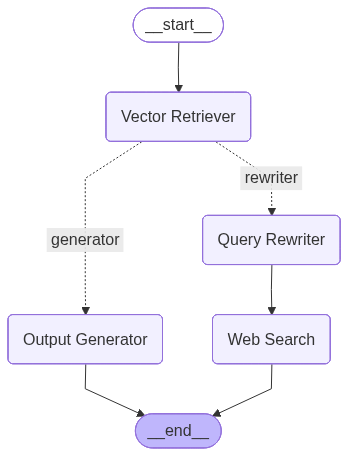

In [25]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod
display(Image(app.get_graph(xray=True).draw_mermaid_png()))